# Notebook 03 — H1 Main-Effect Model

**Dissertation:** *Beyond Money: Who Responds to Intergenerational Appeals for Sustainable Cooperation?*

This notebook evaluates Hypothesis 1 using a three-level mixed-effects linear probability model. The outcome variable is the round-level indicator of green choice behaviour `extract_green_choice)`. To accommodate the hierarchical structure of the experimental data, random intercepts are estimated for sessions and participants, reflecting `decision rounds` nested within `participants` and participants nested within `sessions`. This specification accounts for within-participant dependence and session-level heterogeneity associated with treatment assignment.

Two specifications are estimated per study:
- **Primary** — `liberal_z + treatment + round_c`, the lean confirmatory specification.
- **Robustness check** — the primary specification plus the full pre-treatment covariate set (age, gender, education, ethnicity, trust in scientists, and the Prolific-only controls where available), to assess whether the `liberal_z` estimate is sensitive to demographic confounding. Ideology, unlike treatment, is not randomly assigned, so this check is informative even though treatment itself needs no such adjustment.

## 1 · Setup


In [1]:
# Cell 1: Imports and global configuration
import warnings
import os
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.regression.mixed_linear_model import MixedLM

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 100)

os.makedirs('outputs/tables', exist_ok=True)
os.makedirs('outputs/models', exist_ok=True)

TREAT_MAP = {1: 'IT&GI', 2: 'IT', 3: 'GI', 4: 'NIT&NGI'}
TREAT_ORDER = ['IT&GI', 'IT', 'GI', 'NIT&NGI']

print('Environment ready.')

import matplotlib.pyplot as plt

os.makedirs('outputs/figures', exist_ok=True)

# Consistent treatment palette across all figures in the project.
TREAT_COLORS = {'IT&GI': '#2196F3', 'IT': '#4CAF50', 'GI': '#FF9800', 'NIT&NGI': '#9E9E9E'}
plt.rcParams.update({'figure.dpi': 150})


Environment ready.


## 2 · Load Analytic Datasets

The inputs are the analytic CSVs written by Notebook 01. No additional row deletion is introduced here.


In [2]:
# Cell 2: Load analytic datasets
mt = pd.read_csv('data/mturk_clean.csv')
pr = pd.read_csv('data/prolific_clean.csv')

def prepare_common_fields(df):
    df = df.copy()
    df['treatment_str'] = df['treatment'].map(TREAT_MAP)
    df['round_c'] = df['round'] - df['round'].mean()
    return df

mt = prepare_common_fields(mt)
pr = prepare_common_fields(pr)

print(f"MTurk: {len(mt):,} rows | {mt['participantcode'].nunique():,} participants | {mt['sessioncode'].nunique():,} sessions")
print(f"Prolific: {len(pr):,} rows | {pr['participantcode'].nunique():,} participants | {pr['sessioncode'].nunique():,} sessions")


MTurk: 10,220 rows | 1,022 participants | 308 sessions
Prolific: 10,170 rows | 1,017 participants | 288 sessions


In [3]:
# Cell 3: Shared helpers for model estimation, extraction, and export

def fit_lpm_mixedlm(df, formula, reml=True):
    """
    Three-level mixed-effects linear probability model:

    Level 1: decision rounds
    Level 2: participants
    Level 3: sessions

    Random intercepts are estimated for sessions and participants.
    """
    model = MixedLM.from_formula(
        formula=formula,
        groups='sessioncode',
        re_formula='1',
        vc_formula={'participant': '0 + C(participantcode)'},
        data=df
    )
    result = model.fit(reml=reml, method=['lbfgs', 'bfgs', 'cg', 'powell', 'nm'], maxiter=2000, disp=False)
    if not result.converged:
        print('WARNING: model did not converge with any optimizer in the retry sequence.')
    return result


def model_table(result, model_name, study_label):
    """
    Extract fixed-effect coefficients, standard errors, test statistics,
    p-values, and confidence intervals from a fitted mixed-effects model.

    Variance components are reported separately.
    """
    k_fe = result.model.k_fe
    ci = result.conf_int()
    return pd.DataFrame({
        'term': result.params.index[:k_fe],
        'coef': result.params.values[:k_fe],
        'se': result.bse.values[:k_fe],
        'z': result.tvalues.values[:k_fe],
        'p': result.pvalues.values[:k_fe],
        'ci_low': ci[0].values[:k_fe],
        'ci_high': ci[1].values[:k_fe],
        'model': model_name,
        'study': study_label,
    })


def variance_table(result, model_name, study_label):
    rows = []
    # cov_re reflects the `groups` level -> session, under this specification.
    if hasattr(result, 'cov_re') and result.cov_re is not None:
        try:
            rows.append({'component': 'session_intercept_var', 'value': float(np.asarray(result.cov_re)[0, 0])})
        except Exception:
            pass
    # vcomp reflects the nested 'participant' vc_formula term.
    if hasattr(result, 'vcomp') and result.vcomp is not None:
        vals = np.atleast_1d(result.vcomp)
        for i, v in enumerate(vals, start=1):
            label = 'participant_intercept_var' if i == 1 else f'vc_formula_component_{i}'
            rows.append({'component': label, 'value': float(v)})
    rows.append({'component': 'residual_scale', 'value': float(result.scale)})
    out = pd.DataFrame(rows)
    out['model'] = model_name
    out['study'] = study_label
    return out


def fit_and_export(df, formula, model_name, study_label, prefix):
    result = fit_lpm_mixedlm(df, formula)
    coef_tbl = model_table(result, model_name, study_label)
    var_tbl = variance_table(result, model_name, study_label)
    slug = study_label.lower().replace(' ', '_').replace('(', '').replace(')', '')
    coef_tbl.to_csv(f'outputs/tables/{prefix}_{slug}_coefficients.csv', index=False)
    var_tbl.to_csv(f'outputs/tables/{prefix}_{slug}_variance_components.csv', index=False)
    with open(f'outputs/models/{prefix}_{slug}_summary.txt', 'w') as f:
        f.write(result.summary().as_text())
    return result, coef_tbl, var_tbl


## 3 · H1 Specification

The **primary** specification is the lean confirmatory form: `liberal_z + treatment + round_c`. Treatment is included as a control so that `liberal_z` is estimated net of experimental assignment, per H1's "independently of treatment condition" framing — not because treatment itself needs covariate adjustment (randomisation already handles that).

The **robustness check** adds the full pre-treatment covariate set: age, gender, education, ethnicity, and trust in scientists in both studies, plus risk attitude and short/long-reward preference in Prolific only (collected there but not in MTurk). This tests whether `liberal_z`'s estimate is sensitive to demographic confounding — informative precisely because ideology, unlike treatment, is not randomly assigned. It is reported as a named sensitivity check, not as an alternative primary model.

In [4]:
# Cell 4: Model formulas for H1
H1_FORMULA_PRIMARY = 'extract_green_choice ~ liberal_z + C(treatment, Treatment(reference=4)) + round_c'

H1_FORMULA_ROBUST_MT = (
    'extract_green_choice ~ liberal_z + C(treatment, Treatment(reference=4)) + round_c + '
    'age + C(gender) + C(education) + C(ethnic_min) + trust_scientists_z'
)
H1_FORMULA_ROBUST_PR = (
    'extract_green_choice ~ liberal_z + C(treatment, Treatment(reference=4)) + round_c + '
    'age + C(gender) + C(education) + C(ethnic_min) + trust_scientists_z + '
    'risk_attitude_z + short_long_reward_z'
)

print('Primary formula (both studies):')
print(H1_FORMULA_PRIMARY)
print('\nRobustness-check formula (MTurk):')
print(H1_FORMULA_ROBUST_MT)
print('\nRobustness-check formula (Prolific):')
print(H1_FORMULA_ROBUST_PR)


Primary formula (both studies):
extract_green_choice ~ liberal_z + C(treatment, Treatment(reference=4)) + round_c

Robustness-check formula (MTurk):
extract_green_choice ~ liberal_z + C(treatment, Treatment(reference=4)) + round_c + age + C(gender) + C(education) + C(ethnic_min) + trust_scientists_z

Robustness-check formula (Prolific):
extract_green_choice ~ liberal_z + C(treatment, Treatment(reference=4)) + round_c + age + C(gender) + C(education) + C(ethnic_min) + trust_scientists_z + risk_attitude_z + short_long_reward_z


## 4 · Estimate Primary H1 Models


In [5]:
# Cell 5: Estimate primary H1 models by study
res_h1_mt, coef_h1_mt, var_h1_mt = fit_and_export(
    mt, H1_FORMULA_PRIMARY, model_name='H1 primary', study_label='Study 1 (MTurk)', prefix='h1'
)
res_h1_pr, coef_h1_pr, var_h1_pr = fit_and_export(
    pr, H1_FORMULA_PRIMARY, model_name='H1 primary', study_label='Study 2 (Prolific)', prefix='h1'
)

print('=== Study 1 (MTurk) - Primary ===')
print(res_h1_mt.summary())
print()
print('=== Study 2 (Prolific) - Primary ===')
print(res_h1_pr.summary())


=== Study 1 (MTurk) - Primary ===
                       Mixed Linear Model Regression Results
Model:                  MixedLM       Dependent Variable:       extract_green_choice
No. Observations:       10220         Method:                   REML                
No. Groups:             308           Scale:                    0.1460              
Min. group size:        10            Log-Likelihood:           -5365.0033          
Max. group size:        40            Converged:                Yes                 
Mean group size:        33.2                                                        
------------------------------------------------------------------------------------
                                          Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------
Intercept                                  0.153    0.017  8.899 0.000  0.119  0.186
C(treatment, Treatment(reference=4))[T.1]  0.194    0.0

## 5 · Robustness Check — Full Covariate Adjustment

Retained as a distinct specification rather than replacing the primary model. This is not a duplicate of the primary model; it is a fuller-adjustment version used to show whether the focal `liberal_z` and treatment effects persist once demographic confounders are added, while the primary model above remains the confirmatory H1 test.


In [6]:
# Cell 6: Robustness-check models by study (full covariate adjustment)
res_h1_mt_robust, coef_h1_mt_robust, var_h1_mt_robust = fit_and_export(
    mt, H1_FORMULA_ROBUST_MT, model_name='H1 robustness (full controls)', study_label='Study 1 (MTurk)', prefix='h1_robust'
)
res_h1_pr_robust, coef_h1_pr_robust, var_h1_pr_robust = fit_and_export(
    pr, H1_FORMULA_ROBUST_PR, model_name='H1 robustness (full controls)', study_label='Study 2 (Prolific)', prefix='h1_robust'
)

print('=== Study 1 (MTurk) - Robustness check ===')
print(res_h1_mt_robust.summary())
print()
print('=== Study 2 (Prolific) - Robustness check ===')
print(res_h1_pr_robust.summary())


=== Study 1 (MTurk) - Robustness check ===
                       Mixed Linear Model Regression Results
Model:                  MixedLM       Dependent Variable:       extract_green_choice
No. Observations:       10220         Method:                   REML                
No. Groups:             308           Scale:                    0.1462              
Min. group size:        10            Log-Likelihood:           -5401.4245          
Max. group size:        40            Converged:                Yes                 
Mean group size:        33.2                                                        
------------------------------------------------------------------------------------
                                          Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------
Intercept                                  0.121    0.041  2.967 0.003  0.041  0.200
C(treatment, Treatment(reference=4))[T.1]  0.1

## 6 · Sensitivity Comparison and Consolidated Exports

The table below places the focal H1 terms — `liberal_z` and the treatment contrasts — from the primary and robustness-check specifications side by side, so any sensitivity to the added covariates is visible directly rather than requiring a re-read of both full summaries. Coefficient and variance-component tables for both specifications are then exported separately, so primary and sensitivity-check estimates remain distinguishable in any downstream table or narrative text.


In [7]:
# Cell 7: Sensitivity comparison and consolidated exports
focal_terms = ['liberal_z',
               'C(treatment, Treatment(reference=4))[T.1]',
               'C(treatment, Treatment(reference=4))[T.2]',
               'C(treatment, Treatment(reference=4))[T.3]']

comparison_rows = []
for spec_label, tbl in [
    ('Primary', coef_h1_mt), ('Robustness (full controls)', coef_h1_mt_robust),
]:
    sub = tbl[tbl['term'].isin(focal_terms)].copy()
    sub.insert(0, 'spec', spec_label)
    comparison_rows.append(sub)
for spec_label, tbl in [
    ('Primary', coef_h1_pr), ('Robustness (full controls)', coef_h1_pr_robust),
]:
    sub = tbl[tbl['term'].isin(focal_terms)].copy()
    sub.insert(0, 'spec', spec_label)
    comparison_rows.append(sub)

h1_comparison = pd.concat(comparison_rows, ignore_index=True)
h1_comparison = h1_comparison[['study', 'spec', 'term', 'coef', 'se', 'z', 'p', 'ci_low', 'ci_high']]
h1_comparison.to_csv('outputs/tables/h1_primary_vs_robustness_comparison.csv', index=False)

print('H1 focal terms: primary vs. robustness-check specification')
print(h1_comparison.to_string(index=False))

coef_all = pd.concat([coef_h1_mt, coef_h1_pr, coef_h1_mt_robust, coef_h1_pr_robust], ignore_index=True)
var_all = pd.concat([var_h1_mt, var_h1_pr, var_h1_mt_robust, var_h1_pr_robust], ignore_index=True)

coef_all.to_csv('outputs/tables/h1_all_coefficients.csv', index=False)
var_all.to_csv('outputs/tables/h1_all_variance_components.csv', index=False)

print('\nExported primary and robustness-check outputs for H1.')


H1 focal terms: primary vs. robustness-check specification
             study                       spec                                      term    coef     se       z      p  ci_low  ci_high
   Study 1 (MTurk)                    Primary C(treatment, Treatment(reference=4))[T.1]  0.1935 0.0245  7.8941 0.0000  0.1455   0.2416
   Study 1 (MTurk)                    Primary C(treatment, Treatment(reference=4))[T.2]  0.1158 0.0251  4.6161 0.0000  0.0666   0.1650
   Study 1 (MTurk)                    Primary C(treatment, Treatment(reference=4))[T.3]  0.1386 0.0248  5.5920 0.0000  0.0900   0.1872
   Study 1 (MTurk)                    Primary                                 liberal_z -0.0044 0.0072 -0.6052 0.5450 -0.0186   0.0098
   Study 1 (MTurk) Robustness (full controls) C(treatment, Treatment(reference=4))[T.1]  0.1926 0.0290  6.6420 0.0000  0.1358   0.2494
   Study 1 (MTurk) Robustness (full controls) C(treatment, Treatment(reference=4))[T.2]  0.1147 0.0298  3.8508 0.0001  0.0563   0.1

## 7 · Figure — Treatment Effects and the Ideology Main Effect

The figure below plots the fixed-effect estimates from the primary H1 specification with 95% confidence intervals: the three treatment contrasts against the pure control condition, and the ideology coefficient that constitutes the test of H1.

Presenting both quantities on a common scale makes the central comparison of the chapter legible at a glance. The treatment contrasts are estimated well away from zero, establishing that the manipulations moved behaviour; the ideology coefficient is estimated tightly *around* zero, indicating not merely a failure to reach significance but a precisely bounded absence of association. The distinction matters for interpretation: a wide interval spanning zero would signal an uninformative test, whereas a narrow one licenses the stronger claim that any ideological difference in green choice is negligible in magnitude.

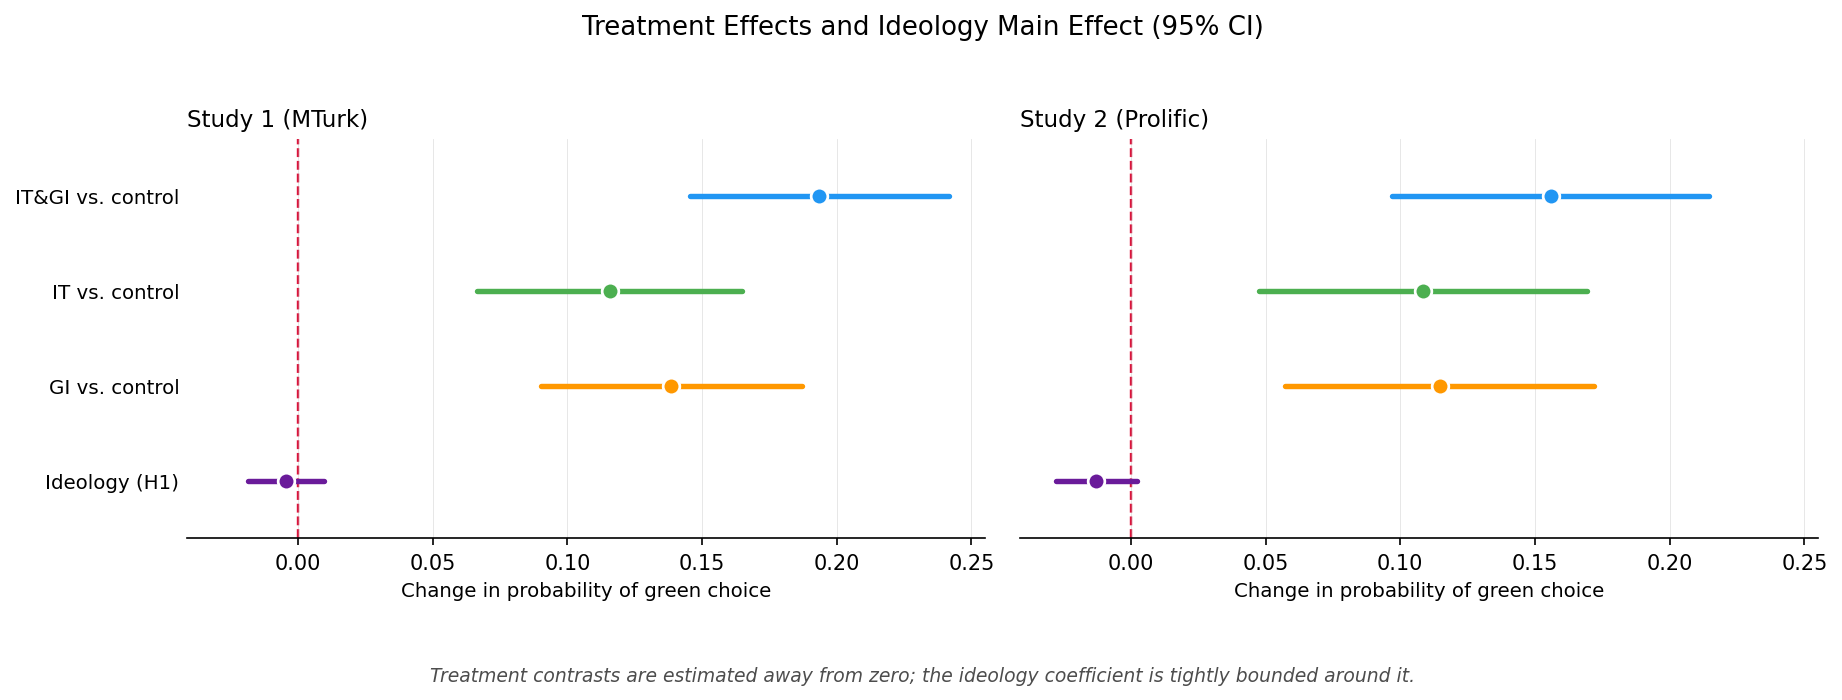

In [8]:
# Cell 8: Figure — treatment effects and the ideology main effect (H1 primary)
FOREST_TERMS = [
    ('C(treatment, Treatment(reference=4))[T.1]', 'IT&GI vs. control', 'IT&GI'),
    ('C(treatment, Treatment(reference=4))[T.2]', 'IT vs. control',    'IT'),
    ('C(treatment, Treatment(reference=4))[T.3]', 'GI vs. control',    'GI'),
    ('liberal_z',                                  'Ideology (H1)',    None),
]

fig, axes = plt.subplots(1, 2, figsize=(12.4, 3.9), sharex=True, sharey=True)

for ax, (res, study) in zip(axes, [(res_h1_mt, 'Study 1 (MTurk)'),
                                    (res_h1_pr, 'Study 2 (Prolific)')]):
    ci = res.conf_int()
    ylabels = []
    for i, (term, label, treat) in enumerate(reversed(FOREST_TERMS)):
        b, lo, hi = res.params[term], ci.loc[term, 0], ci.loc[term, 1]
        colour = TREAT_COLORS[treat] if treat else '#6A1B9A'
        ax.plot([lo, hi], [i, i], color=colour, lw=2.6, solid_capstyle='round', zorder=2)
        ax.plot(b, i, 'o', color=colour, ms=8, mec='white', mew=1.3, zorder=3)
        ylabels.append(label)
    ax.axvline(0, color='crimson', ls='--', lw=1.15, zorder=1)
    ax.set_yticks(range(len(FOREST_TERMS)))
    ax.set_yticklabels(ylabels, fontsize=9.5)
    ax.set_ylim(-0.6, len(FOREST_TERMS) - 0.4)
    ax.set_title(study, fontsize=11, loc='left')
    ax.set_xlabel('Change in probability of green choice', fontsize=9.5)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.tick_params(axis='y', length=0)
    ax.grid(axis='x', lw=0.4, alpha=0.35)

fig.suptitle('Treatment Effects and Ideology Main Effect (95% CI)', fontsize=12.5, y=1.04)
fig.text(0.5, -0.10,
         'Treatment contrasts are estimated away from zero; the ideology coefficient is tightly bounded around it.',
         ha='center', fontsize=9, style='italic', color='0.3')
plt.tight_layout()
plt.savefig('outputs/figures/fig_h1_treatment_and_ideology.png', dpi=200, bbox_inches='tight')
plt.show()